In [13]:
import kagglehub
import pandas as pd
import sqlite3
from pathlib import Path
from pydantic import BaseModel, field_validator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime

In [3]:
# Download latest version
path = kagglehub.dataset_download("minahilfatima12328/lifestyle-and-sleep-patterns")
print("Path to dataset files:", path)
dataset_dir = Path(path)
csv_files = list(dataset_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV File found in the Kaggle Dataset")
csv_path = csv_files[0]
print(f"Using Dataset: {csv_path.name}")

100%|██████████████████████████████████████| 2.54k/2.54k [00:00<00:00, 1.85MB/s]

Extracting files...
Path to dataset files: /Users/john/.cache/kagglehub/datasets/minahilfatima12328/lifestyle-and-sleep-patterns/versions/1
Using Dataset: Sleep_health_and_lifestyle_dataset.csv


In [4]:
df = pd.read_csv(csv_path)

In [6]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [11]:
df  = df.dropna(subset=['Sleep Disorder'])

In [19]:
df['Sleep Disorder'].unique()

array(['Sleep Apnea', 'Insomnia'], dtype=object)

<Axes: title={'center': 'Distribution of Sleep Duration'}, ylabel='Frequency'>

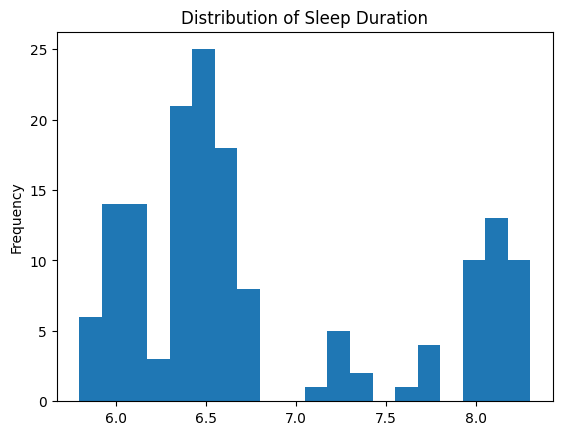

In [12]:
df['Sleep Duration'].plot(kind='hist', bins=20, title='Distribution of Sleep Duration')

📌 A. Sleep Duration vs Sleep Quality

What to explore: Is there a relationship between how long people sleep and how they rate their sleep quality?

How: Create a scatter plot or box plot with sleep duration on the x-axis and sleep quality on the y-axis.

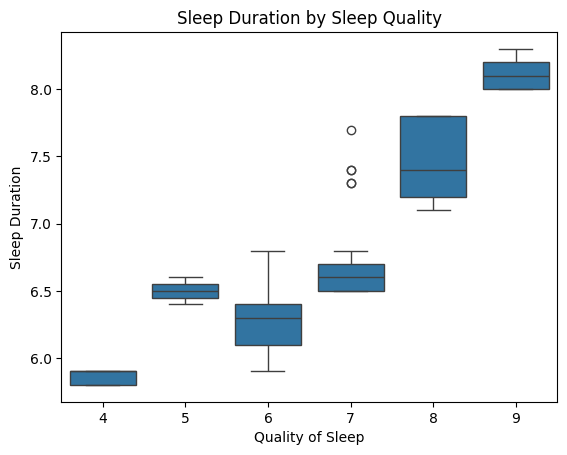

In [15]:
sns.boxplot(x='Quality of Sleep', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Sleep Quality')
plt.show()

📌B. Stress Level and Sleep Disorders

What to explore: Are higher stress levels associated with a higher likelihood of having a sleep disorder?

How: Group by Stress_Level and compare the proportion of individuals with a sleep disorder.

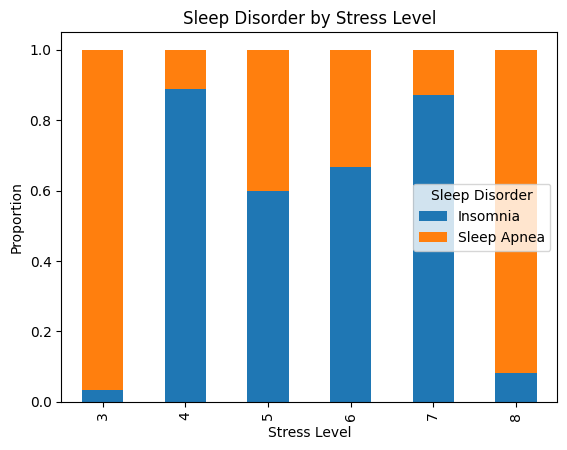

In [16]:
pd.crosstab(df['Stress Level'], df['Sleep Disorder'], normalize='index')\
  .plot(kind='bar', stacked=True)
plt.title('Sleep Disorder by Stress Level')
plt.ylabel('Proportion')
plt.show()

📌 C. Physical Activity and Sleep Quality

What to explore: Do people who engage in more physical activity report better sleep quality?

How: Correlation heatmap or bar plot grouped by activity levels.

In [21]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

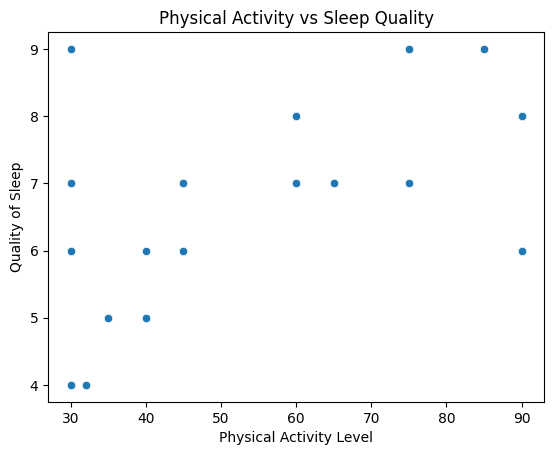

In [23]:
sns.scatterplot(x='Physical Activity Level', y='Quality of Sleep', data=df)
plt.title('Physical Activity vs Sleep Quality')
plt.show()


D. BMI and Sleep Disorders

What to explore: Is BMI a predictor of sleep disorders?

How: Box plot or logistic regression.



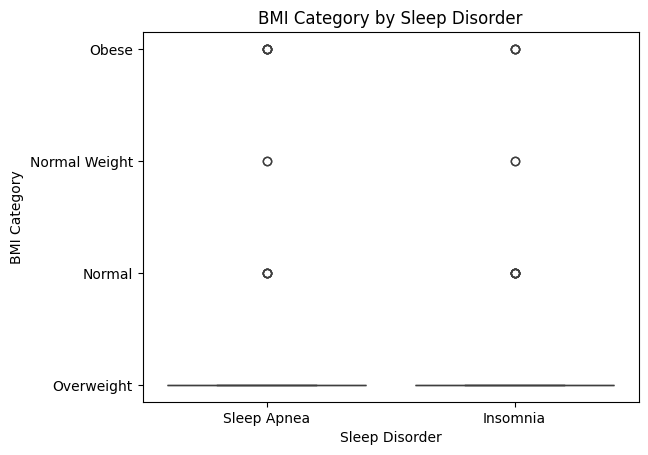

In [24]:
sns.boxplot(x='Sleep Disorder', y='BMI Category', data=df)
plt.title('BMI Category by Sleep Disorder')
plt.show()

## 1. Demographics & Sleep Patterns

📌 A. Sleep Duration by Gender

Plot: Box plot or violin plot

Insight: Do men and women sleep for different average durations?

<Axes: xlabel='Gender', ylabel='Sleep Duration'>

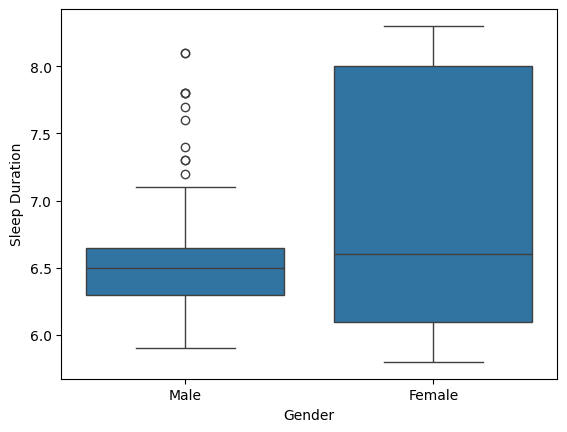

In [26]:
sns.boxplot(x='Gender', y='Sleep Duration', data=df)

B. Sleep Quality by Age Group

Plot: Line plot or bar plot with binned age groups

Insight: Does sleep quality decline with age?



/var/folders/zs/5f511r4n06z0wpsxfpxw7vsw0000gn/T/ipykernel_29655/1187016930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_Group'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100],


<Axes: xlabel='Age_Group', ylabel='Quality of Sleep'>

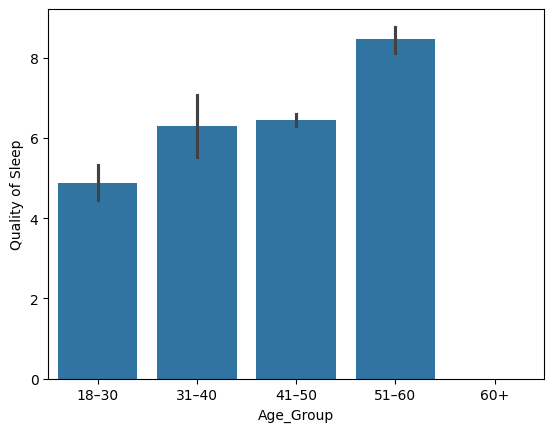

In [30]:
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100],
                         labels=['18–30', '31–40', '41–50', '51–60', '60+'])
sns.barplot(x='Age_Group', y='Quality of Sleep', data=df)

📌 C. Occupation vs Sleep Disorder

Plot: Bar plot

Insight: Are certain jobs more prone to sleep disorders?

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sales Representative'),
  Text(1, 0, 'Software Engineer'),
  Text(2, 0, 'Teacher'),
  Text(3, 0, 'Nurse'),
  Text(4, 0, 'Doctor'),
  Text(5, 0, 'Scientist'),
  Text(6, 0, 'Lawyer'),
  Text(7, 0, 'Accountant'),
  Text(8, 0, 'Engineer'),
  Text(9, 0, 'Salesperson')])

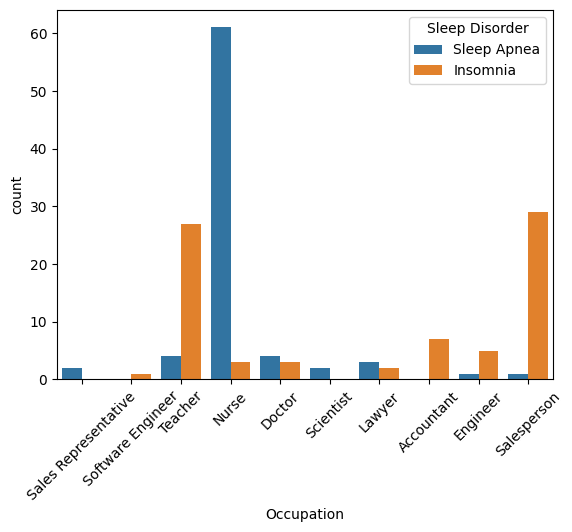

In [32]:
sns.countplot(x='Occupation', hue='Sleep Disorder', data=df)
plt.xticks(rotation=45)

## 💓 2. Health Metrics & Lifestyle

📌 D. Daily Steps vs Sleep Quality

Plot: Scatter plot

Insight: Does physical movement during the day relate to better sleep?

<Axes: xlabel='Daily Steps', ylabel='Quality of Sleep'>

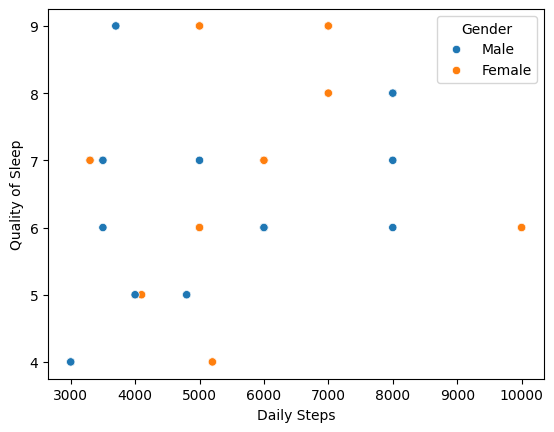

In [34]:
sns.scatterplot(x='Daily Steps', y='Quality of Sleep', hue='Gender', data=df)

📌 E. Heart Rate vs Sleep Duration

Plot: Scatter plot with regression line

Insight: Do people with higher resting heart rates sleep less?


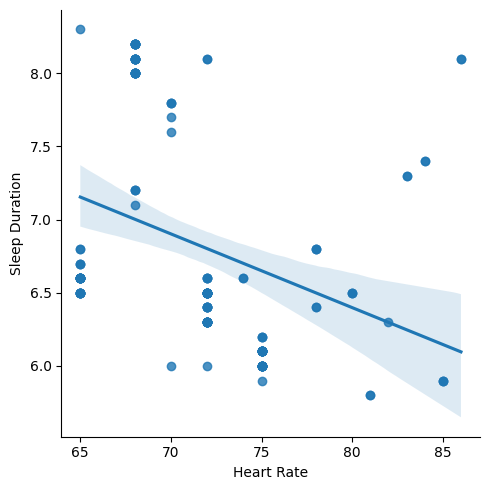

In [36]:
sns.lmplot(x='Heart Rate', y='Sleep Duration', data=df)

📌 F. BMI Category vs Sleep Quality

Plot: Box plot or bar plot

Insight: Are underweight/overweight individuals reporting different sleep quality?

<Axes: xlabel='BMI Category', ylabel='Quality of Sleep'>

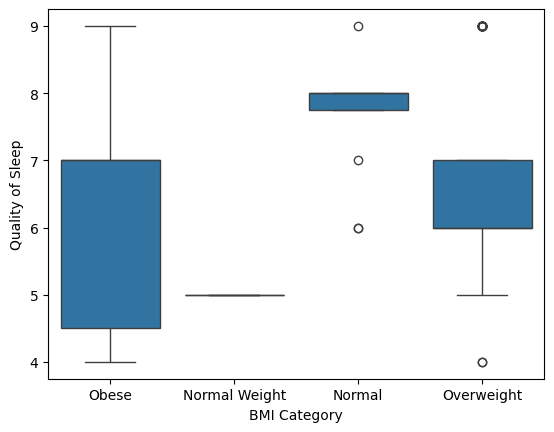

In [37]:
sns.boxplot(x='BMI Category', y='Quality of Sleep', data=df)

📌 G. Stress Level vs Sleep Duration

Plot: Violin plot

Insight: Is higher stress linked to shorter sleep?

<Axes: xlabel='Stress Level', ylabel='Sleep Duration'>

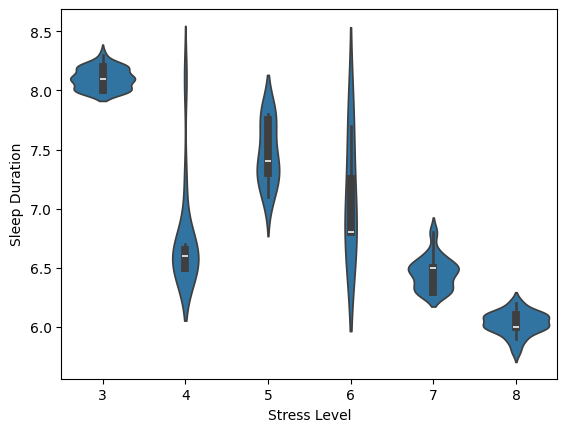

In [38]:
sns.violinplot(x='Stress Level', y='Sleep Duration', data=df)


## 🧠 3. Multivariate / Advanced Visuals

📌 H. Pairplot of Health Indicators

Plot: Pairplot

Insight: Visualize relationships among numerical features like Heart Rate, Steps, Duration, etc.

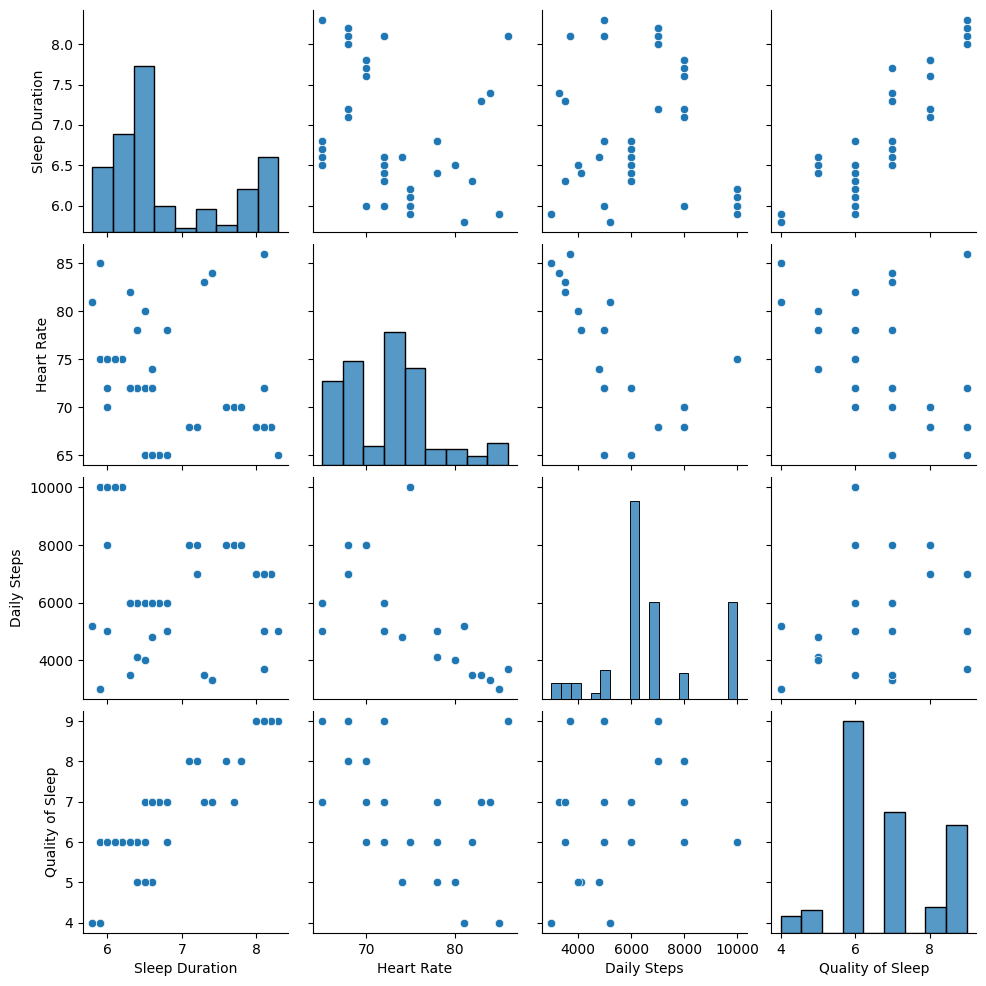

In [40]:
sns.pairplot(df[['Sleep Duration', 'Heart Rate', 'Daily Steps', 'Quality of Sleep']])

📌 I. Heatmap of Average Sleep Quality by Occupation and Gender

Plot: Heatmap (pivot table)

Insight: Are certain occupations and genders more prone to poor sleep?

<Axes: xlabel='Gender', ylabel='Occupation'>

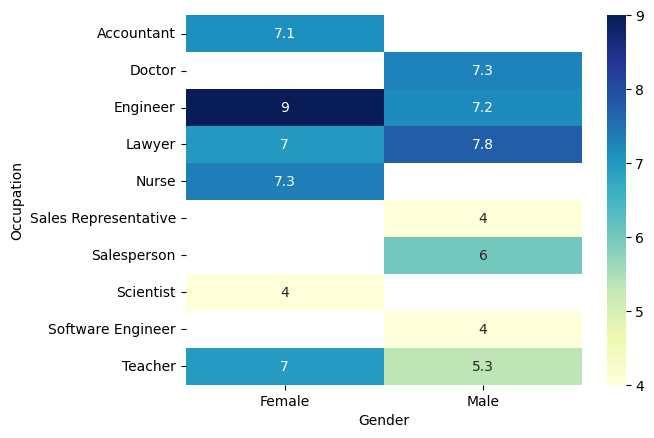

In [41]:
pivot = df.pivot_table(values='Quality of Sleep', index='Occupation', columns='Gender')
sns.heatmap(pivot, annot=True, cmap='YlGnBu')

📌 J. Stacked Bar Plot of Sleep Disorders by Age Group

Plot: Stacked bar

Insight: Which age groups show higher sleep disorder prevalence?

<Axes: xlabel='Age_Group'>

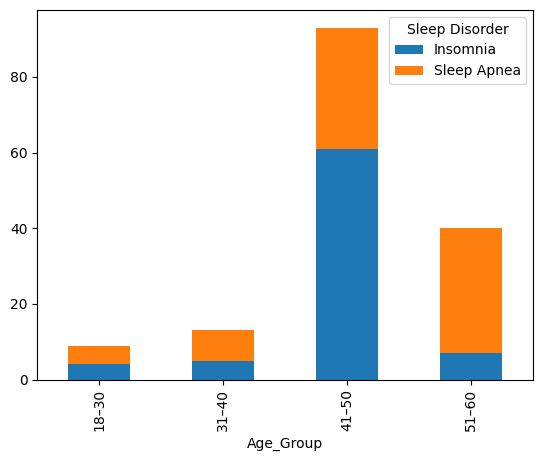

In [42]:
age_disorder = pd.crosstab(df['Age_Group'], df['Sleep Disorder'])
age_disorder.plot(kind='bar', stacked=True)

## 🧠 2. Predictive Modeling Ideas
### 🤖 A. Predict Sleep Disorder (Yes/No)

Goal: Use features like stress level, BMI, blood pressure, etc. to predict if someone has a sleep disorder.

How:

Encode categorical variables

Split data into train/test

Use models like Logistic Regression, Random Forest, or XGBoost

Evaluate with accuracy, F1 score, etc.

In [44]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Age_Group'],
      dtype='object')

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Drop 'Person ID' (not useful for prediction)
# df = df.drop(columns=['Person ID'])

# Encode categorical columns
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoder for decoding later if needed

# Split features and target
X = df.drop(columns=['Sleep Disorder','Age_Group'])
y = df['Sleep Disorder']


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



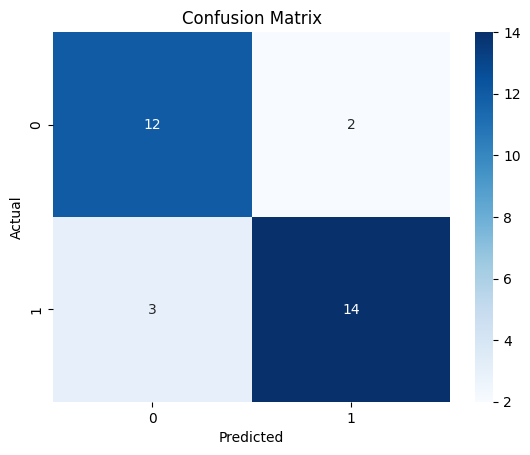

In [56]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoders['Sleep Disorder'].classes_,
            yticklabels=label_encoders['Sleep Disorder'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()